In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

print(train.shape)
print(test.shape)
train.head()

(891, 12)
(418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


看基本信息


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


看一下缺失

In [5]:
train.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

标签分布

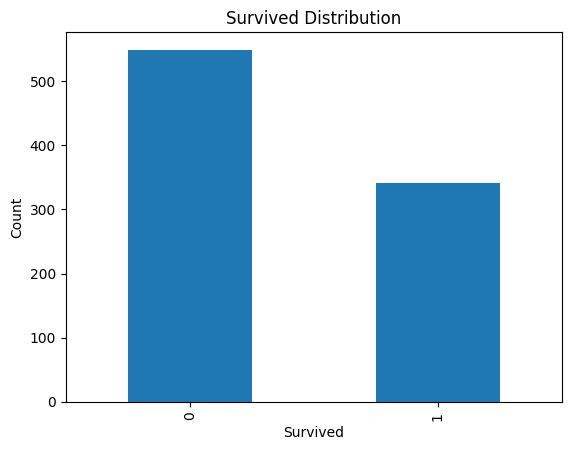

In [7]:
train["Survived"].value_counts()
train["Survived"].value_counts().plot(kind="bar")
plt.title("Survived Distribution")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

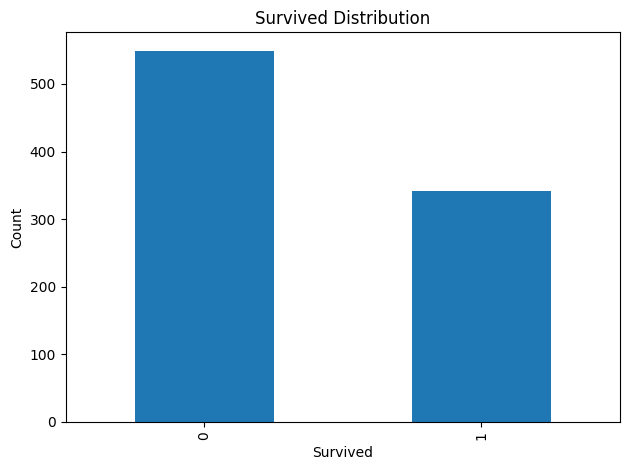

In [8]:
ax = train["Survived"].value_counts().plot(kind="bar")
plt.title("Survived Distribution")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../outputs/figures/survived_distribution.png")
plt.show()

看性别和生存率

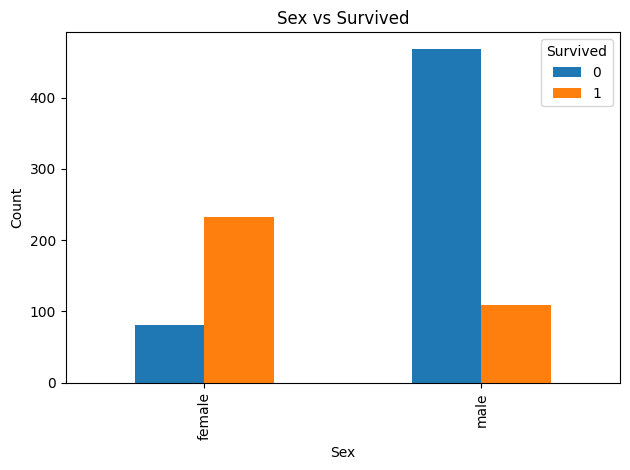

In [10]:
pd.crosstab(train["Sex"], train["Survived"])
pd.crosstab(train["Sex"], train["Survived"]).plot(kind="bar")
plt.title("Sex vs Survived")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../outputs/figures/sex_vs_survived.png")
plt.show()

看舱位和生存率

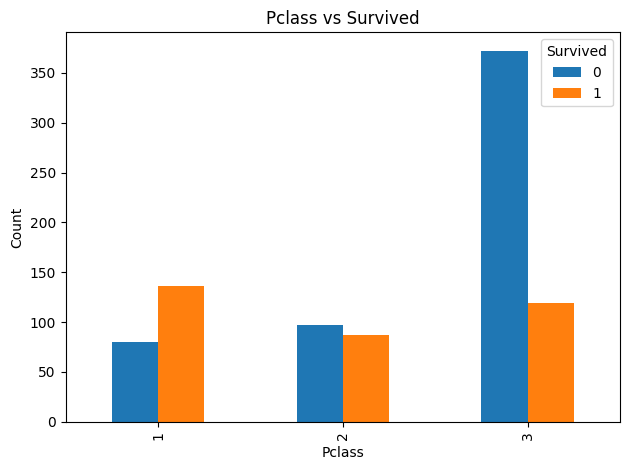

In [12]:
pd.crosstab(train["Pclass"], train["Survived"])
pd.crosstab(train["Pclass"], train["Survived"]).plot(kind="bar")
plt.title("Pclass vs Survived")
plt.xlabel("Pclass")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../outputs/figures/pclass_vs_survived.png")
plt.show()

看年龄分布

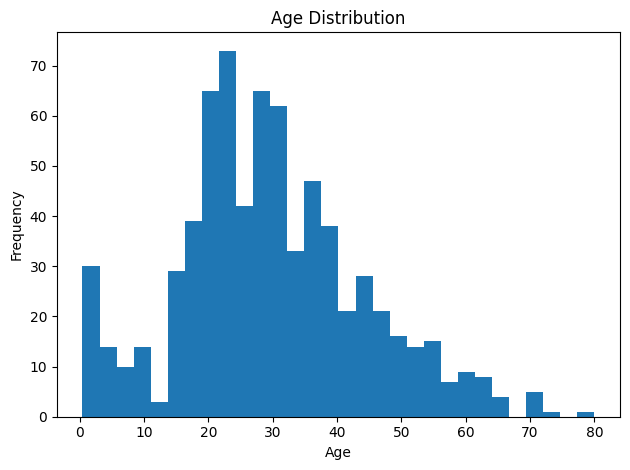

In [13]:
train["Age"].plot(kind="hist", bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.tight_layout()
plt.savefig("../outputs/figures/age_distribution.png")
plt.show()

## Initial Findings

1. The training set has 891 rows and 12 columns, while the test set has 418 rows and 11 columns.
2. Cabin has too many missing values, and Age also has missing values that need handling later.
3. Female passengers seem to have a higher survival rate than male passengers.
4. Passengers in higher classes seem more likely to survive.(higher servival rate/probability)
5. Age distribution is uneven and may require imputation before modeling.